# Notes
Helpful info from udemy course: 
https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb

# GitHub Repository:
https://github.com/mpennino/Future_DW_NO3

In [2]:
# Import libraries
import pandas as pd
import torch
import torch.nn as nn

import pyarrow as pa
import pyarrow.parquet as pq


In [3]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [4]:
# Load Observation Dataset
# DATA = readRDS(paste0(strap_dir,'Data/Models/RF_bi_model_All_DATA_all_vars_','Trends_Conc_PWS_GW_05to20', '.rds'))
#future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/StRAPs/StRAP4/SSWR.405.1_Future_DW/Data/'
future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/'


dataset1 = 'Dataset_RF_Model_SW_COMIDS.csv'
#dataset1 = 'Dataset_RF_Model_GW_COMIDS.csv'

input_data_ = pd.read_csv(future_dir+dataset1)
input_data_.head(3)

,COMID,viol_freq,PopDen2010Ws,PctForest2019Ws,PctCrop2019Ws,precip9120ws,tmean9120ws,BFIWs,permws,N_TW2012Ws,RockNWs,N_Surp_kgsqkm_2017ws,ElevWs,Fe2O3Ws,NHDslope_Pct_Ws,Viol_Class
0,12558,0,21.5842,40.60,7.02,446.418385,9.098713,64.9434,7.301968,3.639743,413.0962,1281.176035,1745.8597,2.7018,9.338324,0
1,12564,0,4.8193,63.36,0.00,454.415442,9.029232,65.0000,8.889206,3.607679,422.7846,350.849192,1866.1304,3.6657,15.421640,0
2,12606,0,1.1832,68.73,0.00,678.346321,2.958328,69.1535,14.232988,4.387261,27.3868,492.682789,2905.9906,2.5098,8.917415,0


In [5]:
input_data_.shape


(14934, 16)

In [6]:
names_list = input_data_.columns.tolist()
print(names_list) 

['COMID', 'viol_freq', 'PopDen2010Ws', 'PctForest2019Ws', 'PctCrop2019Ws', 'precip9120ws', 'tmean9120ws', 'BFIWs', 'permws', 'N_TW2012Ws', 'RockNWs', 'N_Surp_kgsqkm_2017ws', 'ElevWs', 'Fe2O3Ws', 'NHDslope_Pct_Ws', 'Viol_Class']


In [7]:
# Remove extra fields
# For Surface Water Dataset (,'AgDrain_pctWs','Hillslope_PctWs','BFIWs')
#input_data = input_data_.drop(columns=['HUC12','viol_freq','PopDen2010Ws','WaterInputWs','wdrw_LDWs','FertWs','CBNFWs','ManureWs','Septic_km2Cat']) 
input_data = input_data_.drop(columns=['COMID','viol_freq']) 

# For Groundwater Dataset
#input_data = input_data_.drop(columns=['HUC12','viol_freq','PopDen2010Cat','AgKffactCat','Septic_km2Cat','AgDrain_pctCat','WaterInputCat','wdrw_LDCat','BFICat','Hillslope_PctCat']) 

input_data.head(3)


,PopDen2010Ws,PctForest2019Ws,PctCrop2019Ws,precip9120ws,tmean9120ws,BFIWs,permws,N_TW2012Ws,RockNWs,N_Surp_kgsqkm_2017ws,ElevWs,Fe2O3Ws,NHDslope_Pct_Ws,Viol_Class
0,21.5842,40.60,7.02,446.418385,9.098713,64.9434,7.301968,3.639743,413.0962,1281.176035,1745.8597,2.7018,9.338324,0
1,4.8193,63.36,0.00,454.415442,9.029232,65.0000,8.889206,3.607679,422.7846,350.849192,1866.1304,3.6657,15.421640,0
2,1.1832,68.73,0.00,678.346321,2.958328,69.1535,14.232988,4.387261,27.3868,492.682789,2905.9906,2.5098,8.917415,0


In [8]:
input_data.shape,input_data_.shape

((14934, 14), (14934, 16))

In [9]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

# Create Balanced Dataset


In [10]:
print(input_data['Viol_Class'].value_counts())

Viol_Class
0    14893
1       41
Name: count, dtype: int64


In [11]:
# Save Preditor Data for SHAP Analysis
X_input_data = input_data.drop(columns=['Viol_Class']).values
X_input_data.shape


(14934, 13)

In [12]:
# Convert to tensor data
X_input_data = torch.from_numpy(X_input_data).type(torch.float)
X_input_data.shape,X_input_data.dtype

(torch.Size([14934, 13]), torch.float32)

In [13]:
min_size = input_data['Viol_Class'].value_counts().min()
min_size


np.int64(41)

In [14]:
#
# Find the size of the smallest class
min_size = input_data['Viol_Class'].value_counts().min()

min_size  = min_size * 10

# Sample exactly 'min_size' elements from each binary group
#balanced_df = input_data.groupby('Viol_Class').sample(n=min_size, random_state=42).reset_index(drop=True)

# If increasing the min_size, you can use the 'replace=True' argument to allow for sampling with replacement
balanced_df = input_data.groupby('Viol_Class').sample(n=min_size, random_state=42, replace=True).reset_index(drop=True)

print(balanced_df['Viol_Class'].value_counts())

Viol_Class
0    410
1    410
Name: count, dtype: int64


# Transform data to torch tensor


In [15]:
# Convert to tensors and split into train and test sets
from sklearn.model_selection import train_test_split
#X = input_data.drop(columns=['Viol_Class']).values # when use this the model just predicts the majority class
#y = input_data['Viol_Class'].values
X = balanced_df.drop(columns=['Viol_Class']).values
y = balanced_df['Viol_Class'].values

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Make a copy to use later
X_full = X.clone()
y_full = y.clone()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=2
)

#X_train[:5], y_train[:5]

C:\Users\MPennino\AppData\Local\Temp\ipykernel_31708\3056076170.py:10: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at D:\bld\libtorch_1784990676194\work\torch\csrc\utils\tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


In [16]:
# print(y_train.unique(return_counts=True)),
# print(y_test.unique(return_counts=True)),

In [17]:
#X.dtype, y.dtype, X.size(), y.size()

# Create NN Model

In [18]:
nrows = X_train.size()[0]
ncols = X_train.size()[1]
nrows,ncols

(656, 13)

In [25]:
# Build SW model with non-linear activation function
from torch import nn

featureNum = 5
class BinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=ncols, out_features=featureNum) 
        self.layer_2 = nn.Linear(in_features=featureNum, out_features=featureNum)
        self.layer_3 = nn.Linear(in_features=featureNum, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function (for non-linearity)
        #self.relu= nn.leakyReLU() # <- add in ReLU activation function (for non-linearity)
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model1 = BinaryClassifier().to(device)
print(model1)

BinaryClassifier(
  (layer_1): Linear(in_features=13, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=5, bias=True)
  (layer_3): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
)


In [27]:
# # Build GW model with non-linear activation function
# from torch import nn

# featureNum = 5
# class BinaryClassifier(nn.Module):
#     def __init__(self):
#         super().__init__()
#         # This code works for SW HUC12
#         # self.layer_1 = nn.Linear(in_features=ncols, out_features=5) 
#         # self.layer_2 = nn.Linear(in_features=5, out_features=5)
#         # self.layer_3 = nn.Linear(in_features=5, out_features=1)

#         self.layer_1 = nn.Linear(in_features=ncols, out_features=featureNum) 
#         self.layer_2 = nn.Linear(in_features=featureNum, out_features=featureNum)
#         self.layer_3 = nn.Linear(in_features=featureNum, out_features=featureNum)
#         self.layer_4 = nn.Linear(in_features=featureNum, out_features=featureNum)
#         self.layer_5 = nn.Linear(in_features=featureNum, out_features=1)

#         self.relu = nn.ReLU(0.1) # <- add in ReLU activation function (for non-linearity)
#         #self.relu= nn.leakyReLU() # <- add in ReLU activation function (for non-linearity)
#         # Can also put sigmoid in the model 
#         # This would mean you don't need to use it on the predictions
#         # self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#       # Intersperse the ReLU activation function between layers
#        #return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
#        #return self.layer_4(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x))))))
#        return self.layer_5(self.layer_4(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))))

# model1 = BinaryClassifier().to(device)
#print(model2)

In [19]:
import torch
import torch.nn as nn

class ImprovedBinaryClassifier(nn.Module):
    def __init__(self, input_dim=ncols, hidden_dim=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.1),             # Prevents dead neurons
            nn.BatchNorm1d(hidden_dim),     # Stabilizes training
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),                # Prevents overfitting
            
            nn.Linear(hidden_dim, 1)        # Outputs raw logits (No Sigmoid here!)
        )
        
    def forward(self, x):
        return self.network(x)

model1 = ImprovedBinaryClassifier().to(device)


In [26]:
# Setup loss and optimizer 
loss_fn = nn.BCEWithLogitsLoss()
#optimizer = torch.optim.SGD(model1.parameters(), lr=0.01)
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.01)
#optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.01)

# Train the Model

In [27]:
# Fit the model
torch.manual_seed(42)
epochs = 1000

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # 1. Forward pass
    y_logits = model1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels
    
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss calculates loss using logits
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_pred)
    
    # 3. Optimizer zero grad
    optimizer1.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer1.step()

    ### Testing
    model1.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model1(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
      # 2. Calculate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 18.92454, Accuracy: 43.60% | Test Loss: 14.37664, Test Accuracy: 50.61%
Epoch: 100 | Loss: 0.53471, Accuracy: 69.05% | Test Loss: 0.55345, Test Accuracy: 67.07%
Epoch: 200 | Loss: 0.44814, Accuracy: 79.12% | Test Loss: 0.48496, Test Accuracy: 76.22%
Epoch: 300 | Loss: 0.42423, Accuracy: 80.64% | Test Loss: 0.44214, Test Accuracy: 77.44%
Epoch: 400 | Loss: 0.40727, Accuracy: 80.18% | Test Loss: 0.42533, Test Accuracy: 78.66%
Epoch: 500 | Loss: 0.37781, Accuracy: 82.93% | Test Loss: 0.41041, Test Accuracy: 80.49%
Epoch: 600 | Loss: 0.35302, Accuracy: 85.06% | Test Loss: 0.38905, Test Accuracy: 82.93%
Epoch: 700 | Loss: 0.33687, Accuracy: 86.74% | Test Loss: 0.36931, Test Accuracy: 84.15%
Epoch: 800 | Loss: 0.32335, Accuracy: 86.13% | Test Loss: 0.34952, Test Accuracy: 84.15%
Epoch: 900 | Loss: 0.31926, Accuracy: 87.04% | Test Loss: 0.35026, Test Accuracy: 85.98%


# Model Evaluation Metrics
*PCC, Sensativity, Specificity, AUC

In [28]:
import torchmetrics

# Define your classification task ('binary', 'multiclass', or 'multilabel')
task = "binary"

# Initialize metrics
sensitivity_metric = torchmetrics.classification.Recall(task=task)
specificity_metric = torchmetrics.classification.Specificity(task=task)

# Get model predictions on the test set
model1.eval()
with torch.inference_mode():
    preds = torch.round(torch.sigmoid(model1(X_test))).squeeze()

# get target / observed response values
target = y_test

# Simulated model predictions (logits or probabilities) and ground truth targets
# preds  = torch.tensor([0, 1, 0, 1, 1, 0])
# target = torch.tensor([0, 1, 1, 0, 1, 0])

# Compute metrics
#sensitivity = sensitivity_metric(preds, target)
#specificity = specificity_metric(preds, target)

# Calculate True Positives, True Negatives, False Positives, False Negatives
TP = torch.sum((preds == 1) & (target == 1)).float()
TN = torch.sum((preds == 0) & (target == 0)).float()
FP = torch.sum((preds == 1) & (target == 0)).float()
FN = torch.sum((preds == 0) & (target == 1)).float()

PCC = (TP + TN) / (TP + TN + FP + FN)
sensitivity = TP / (TP + FN )
specificity = TN / (TN + FP )

print(f"PCC: {PCC.item():.4f}")
print(f"Sensitivity (True Positives): {sensitivity.item():.4f}")
print(f"Specificity (True Negatives): {specificity.item():.4f}")

PCC: 0.8537
Sensitivity (True Positives): 0.8353
Specificity (True Negatives): 0.8734


In [29]:
len(preds), len(target)
preds[0:20], target[0:20]

(tensor([0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1.,
         0., 0.]),
 tensor([0., 1., 0., 1., 1., 1., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0.,
         1., 0.]))

In [30]:
# AUC Calculation
from sklearn.metrics import roc_auc_score
import numpy as np

#()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()
model = model1  # model 1 or model2, depending on which model you want to evaluate
#()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()()

model1.eval()
with torch.inference_mode():
    preds = torch.round(torch.sigmoid(model(X_test))).squeeze()

# get target / observed response values
target = y_test

preds2 = preds.detach().cpu().tolist()
target2 = target.detach().cpu().tolist()

len(preds), len(target), type(preds), type(preds2), target2[0:5], preds2[0:5]

# 2. Calculate the AUC Score
auc_score = roc_auc_score(target2, preds2)
print(f"Test AUC: {auc_score:.4f}")

Test AUC: 0.8544


# Make Predictions

# Scenario: Current Period (base year 2020)

In [31]:
# Load Prediction Dataset
dataset = "current_NO3_predictors_catchments.parquet"
pred_data_ = pd.read_parquet(future_dir+dataset) # Read a single Parquet file
#pred_data_ = pd.read_table(future_dir+dataset) # Read a single Parquet file

# Get list of predictors from training dataset
temp = input_data.drop(columns=['Viol_Class'])
names_list = temp.columns.tolist()
#print(names_list)

# Remove extra fields (model predictions won't work unless the prediction dataset has the same fields as the training dataset)
pred_data = pred_data_[names_list]
#pred_data.head(3)
len(pred_data)

2643994

In [32]:
# Convert to Tensor
PRED_DATA = pred_data.values

# Turn data into tensors
PRED_DATA = torch.from_numpy(PRED_DATA).type(torch.float)

# Make Predictions on full HUC12 dataset, for prediction probabilities
model1.eval()
with torch.inference_mode():
    y_probs = torch.sigmoid(model1(PRED_DATA)).squeeze()
    
# Convert from torch to pandas dataframe
y_probs_df = pd.DataFrame(y_probs.cpu().numpy(), columns=['Pred_Viol_Prob'])

# Merge with HUC12 
result2 = pd.concat([pred_data_['COMID'], y_probs_df], axis=1)
len(result2)


2643994

In [33]:
# Save Dataset

filename = 'torch_predictions_current_All_COMID_sw_v2.parquet'
#filename = 'torch_predictions_current_All_COMID_gw.parquet'


table = pa.Table.from_pandas(result2)
pq.write_table(table, future_dir + filename)



# Scenario: Future projection

In [40]:
# Load Dataset
filename = 'future_RCP4.5G_NO3_predictors_HUC12.parquet'
#filename = 'future_RCP8.5G_NO3_predictors_HUC12.parquet'

pred_data_fut_ = pq.read_table(future_dir + filename)
pred_data_fut1 = pred_data_fut_.to_pandas()
pred_data_fut1.shape
pred_data_fut = pred_data_fut1[names_list]
pred_data_fut.shape

(79355, 19)

In [41]:
# Convert to Tensor
PRED_DATA_FUT = pred_data_fut.values

# Turn data into tensors
PRED_DATA_FUT = torch.from_numpy(PRED_DATA_FUT).type(torch.float)

# Make Predictions for prediction probabilities
model1.eval()
with torch.inference_mode():
    y_probs_fut = torch.sigmoid(model1(PRED_DATA_FUT)).squeeze()

# Convert to pd dataframe
y_probs_fut_df = pd.DataFrame(y_probs_fut.cpu().numpy(), columns=['Pred_Viol_Prob'])

# Merge with HUC12 
result_fut = pd.concat([pred_data_fut1['HUC12'], y_probs_fut_df], axis=1)

In [42]:
# Save Results
filename = 'torch_pred_scenario_fut_RCP4.5G_HUC12_sw.parquet'
#filename = 'torch_pred_scenario_fut_RCP4.5G_HUC12_gw.parquet'

table = pa.Table.from_pandas(result_fut)
pq.write_table(table, future_dir + filename)

# Scenario: Increased NUE

In [43]:
filename = 'Scenario_NUE_Incr_Dataset_HUC12.parquet'
pred_data_nue_ = pq.read_table(future_dir + filename)
pred_data_nue1 = pred_data_nue_.to_pandas()
#pred_data_nue1.head(3)
#pred_data_nue = pred_data_nue1.drop(columns=['HUC12']) 
pred_data_nue = pred_data_nue1[names_list]
pred_data_nue.shape


(79355, 19)

In [44]:
# Convert to Tensor
PRED_DATA_NUE = pred_data_nue.values

# Turn data into tensors
PRED_DATA_NUE = torch.from_numpy(PRED_DATA_NUE).type(torch.float)

# Make Predictions for prediction probabilities
model1.eval()
with torch.inference_mode():
    y_probs_nue = torch.sigmoid(model1(PRED_DATA_NUE)).squeeze()

# Convert to pd dataframe
y_probs_nue_df = pd.DataFrame(y_probs_nue.cpu().numpy(), columns=['Pred_Viol_Prob'])

# Merge with HUC12 
result_nue = pd.concat([pred_data_nue1['HUC12'], y_probs_nue_df], axis=1)

In [45]:
# Save Results
filename = 'torch_pred_scenario_nue_HUC12_sw.parquet'
#filename = 'torch_pred_scenario_nue_HUC12_gw.parquet'

table = pa.Table.from_pandas(result_nue)
pq.write_table(table, future_dir + filename)

# Scenario: Increased Productivity

In [46]:
pred_data_prod = pred_data.copy()
pred_data_prod['n_surplus_kgsqkm'] = pred_data_prod['n_surplus_kgsqkm'] * 2
pred_data_prod['n_surplus_kgsqkm'].mean(), pred_data['n_surplus_kgsqkm'].mean()

(np.float64(5180.883660299498), np.float64(2590.441830149749))

In [47]:
# Convert to Tensor
PRED_DATA_PROD = pred_data_prod.values

# Turn data into tensors
PRED_DATA_PROD = torch.from_numpy(PRED_DATA_PROD).type(torch.float)

# Make Predictions for prediction probabilities
model1.eval()
with torch.inference_mode():
    y_probs_prod = torch.sigmoid(model1(PRED_DATA_PROD)).squeeze()

# Convert to pd dataframe
y_probs_prod_df = pd.DataFrame(y_probs_prod.cpu().numpy(), columns=['Pred_Viol_Prob'])

# Merge with HUC12 
result_prod = pd.concat([pred_data_['HUC12'], y_probs_prod_df], axis=1)

In [48]:
# Save Results
#filename = 'torch_pred_scenario_prod_HUC12.parquet'
filename = 'torch_pred_scenario_prod_HUC12_sw.parquet'
#filename = 'torch_pred_scenario_prod_HUC12_gw.parquet'

table = pa.Table.from_pandas(result_prod)
pq.write_table(table, future_dir + filename)

# SHAP Analysis

In [29]:
import numpy as np
import pandas as pd
import sklearn
import shap
import matplotlib.pyplot as plt

In [30]:
# Create Explainer object that can calculate shap values
#explainer = shap.TreeExplainer(random_forest)
#explainer = shap.DeepExplainer(model1,X_train)
#explainer = shap.PartitionExplainer(model1,X_train)
explainer = shap.GradientExplainer(model1,X_train)

In [31]:
#pred_data.head(3)
X_full.shape, X_input_data.shape

(torch.Size([820, 13]), torch.Size([14934, 13]))

In [32]:
X_full.dtype, X_input_data.dtype

(torch.float32, torch.float32)

In [33]:
len(X_input_data)

14934

In [ ]:
# Calculate Shap values
#choosen_instance = X_test.loc[[50]]
#shap_values = explainer.shap_values(choosen_instance)
#shap_values = explainer(X_test) # 8 sec # this a tensor object without field names
#shap_values = explainer(X_full) # 40 sec # this a tensor object without field names
shap_values = explainer(X_input_data) # 11 min 4.3 sec (32,000 rows GW), 3 min for 8,700 rows # this a tensor object without field names
# ~8 min for 15,000 rows

#shap_values = explainer(pred_data) # 20 sec # this a dataframe object with field names, but doesnt work

#shap_values = explainer.shap_values(pred_data)


In [ ]:
#X_test.shape, X_train.shape

(torch.Size([393, 10]), torch.Size([1571, 10]))

In [ ]:
#X_test.numpy().shape, X_train.numpy().shape

((393, 10), (1571, 10))

In [35]:
# Add in feature names to shap_values object
names = input_data.columns.tolist()
names = names[:-1] 
shap_values1 = shap_values
shap_values1.feature_names = names

In [36]:
# Creates a DataFrame of SHAP values
df_shap = pd.DataFrame(
    data=shap_values1[:,:, 0].values, 
    columns=shap_values1[:, :, 0].feature_names
)
df_shap.head(5)

,PopDen2010Ws,PctForest2019Ws,PctCrop2019Ws,precip9120ws,tmean9120ws,BFIWs,permws,N_TW2012Ws,RockNWs,N_Surp_kgsqkm_2017ws,ElevWs,Fe2O3Ws,NHDslope_Pct_Ws
0,3.437590,0.489708,5.093761,0.829861,-2.738359,-0.002474,0.474495,-0.089680,25.163187,14.885246,-13.316676,0.824003,-2.884074
1,5.638458,-2.752098,-1.655649,33.095658,-2.150923,0.022637,1.001268,-0.020997,-3.100745,-37.843870,29.345937,0.200644,-5.231478
2,9.521761,-5.158130,1.910490,5.715797,-4.955820,0.607812,4.216400,-0.297804,-3.050430,0.119188,13.486564,0.325657,-2.387571
3,-4.003451,4.552650,0.523599,34.262796,-2.820154,-0.183821,-2.289766,0.141085,7.134002,37.241991,-8.456880,-0.744382,1.004032
4,4.916525,-4.010515,2.601167,2.172205,-5.866223,0.485441,5.848663,-0.344118,-2.431868,3.671885,4.165400,0.395572,-3.015085


In [37]:
df_shap.shape

(14934, 13)

In [38]:
type(shap_values)

shap._explanation.Explanation

In [74]:
# import sys
# !{sys.executable} -m pip install --upgrade shap matplotlib

C:\Users\MPennino\AppData\Local\Temp\ipykernel_31772\1998641036.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values1[:,:, 0].values, X_input_data.numpy(),feature_names=names) # works if generate shape values based on test dataset


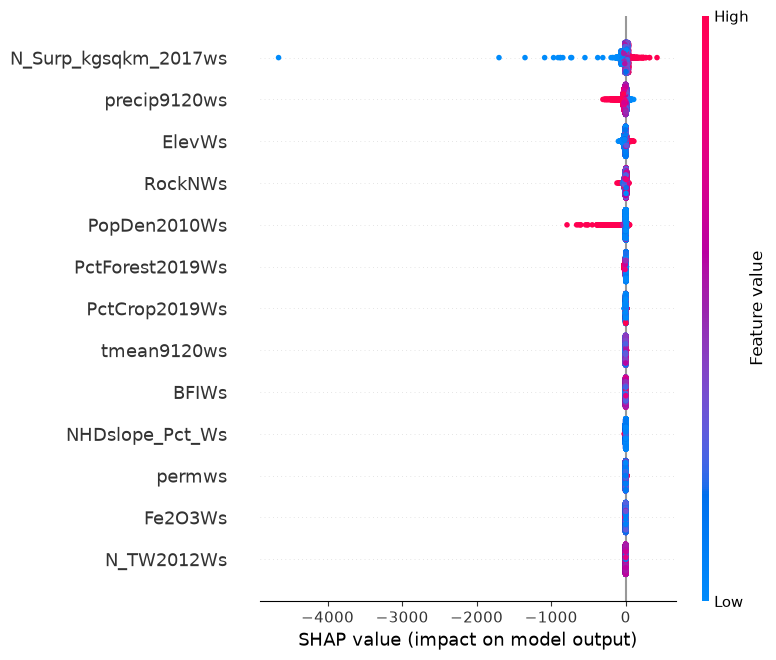

In [39]:

# Visualize
#shap.summary_plot(shap_values[0], X_test.numpy())
#shap.summary_plot(shap_values1[:,:, 0].values, X_test.numpy()) # works but no feature names
#shap.summary_plot(shap_values1[:,:, 0].values, X_test.numpy(),feature_names=names) # works if generate shape values based on test dataset
#shap.summary_plot(shap_values1[:,:, 0].values, X_full.numpy(),feature_names=names) # works if generate shape values based on test dataset

# This one use to work
shap.summary_plot(shap_values1[:,:, 0].values, X_input_data.numpy(),feature_names=names) # works if generate shape values based on test dataset

#shap.summary_plot(shap_values1[:,:, 0].values, input_data[0:393:].drop(columns=['Viol_Class'])) 

In [40]:
df_shap.shape

(14934, 13)

In [42]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
# Save SHAP Results
filename1 = 'torch_SHAP_Values_DF_COMID_All_Observed_sw.parquet'
#filename = 'torch_SHAP_Values_HUC12_All_Observed_gw.parquet'

filename2 = 'torch_SHAP_Values_COMID_All_Observed_sw.parquet'


table1 = pa.Table.from_pandas(df_shap)
table2 = pa.Table.from_pandas(shap_values1)

pq.write_table(table, future_dir + filename1)
pq.write_table(shap_values1, future_dir + filename2)


AttributeError: 'Explanation' object has no attribute 'columns'